# EEG Alpha-Band Age Prediction
## Dataset: Alpha_data.xlsx
### pipelines:
- **Pipeline A**: Seleccion de Caracteristicas (Mutual Information) → Regression
- **Pipeline B**: Reduccion de Dimensionalidad (PCA) → Regression

**Metricas usadas**: MAE, RMSE y R² 


## 0. Dependencias

In [ ]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_validate,
    cross_val_score,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor
import shap
warnings.filterwarnings('ignore')
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 1. Carga y limpieza del dataset

In [8]:
df_raw = pd.read_excel(r'C:\Users\eguen\Documents\Ernesto\Articulos\RedLat\Files\Data\Alpha_data.xlsx')  # ajusta el path si es necesario
df_raw.head()

,Unnamed: 0,Alpha2_canon_EPP_HPC_left,Alpha2_canon_EPP_HPC_right,Alpha2_canon_EPP_PARIET_left,Alpha2_canon_EPP_PARIET_right,Alpha2_canon_EPP_OCC_left,Alpha2_canon_EPP_OCC_right,Alpha2_canon_RPD_HPC_left,Alpha2_canon_RPD_HPC_right,Alpha2_canon_RPD_CING_left,...,IAF_MFG_right,IAF_SFG_left,IAF_SFG_right,IAF_HPC_left,IAF_HPC_right,IAF_INS_left,IAF_INS_right,IAF_OCC_left,IAF_OCC_right,Age
0,0,NaN,7.831277e-03,NaN,1.566255e-02,6.910771e-03,8.989653e-03,10.8,NaN,0.000992,...,8.75,17.750,8.8750,9.000000,13.50,9.0,8.625,8.833333,8.791667,33.0
1,1,NaN,6.847430e-08,NaN,1.369486e-07,6.847430e-08,6.847430e-08,10.2,NaN,NaN,...,NaN,17.000,8.5000,8.500000,12.75,8.5,8.500,8.500000,8.500000,39.0
2,2,NaN,6.847430e-08,NaN,1.369486e-07,6.847430e-08,6.847430e-08,10.2,NaN,NaN,...,NaN,17.000,8.5000,8.500000,12.75,8.5,8.500,8.500000,8.500000,26.0
3,3,NaN,1.347051e-02,NaN,2.694102e-02,2.193269e-02,1.779899e-02,13.8,NaN,NaN,...,NaN,23.375,11.6875,11.500000,17.25,11.5,11.625,11.375000,11.500000,57.0
4,4,0.004465,3.429442e-03,0.005261,6.858885e-03,6.252499e-03,6.697983e-03,12.1,NaN,0.000576,...,NaN,20.125,10.0625,10.083333,15.00,10.0,10.375,10.125000,10.166667,32.0


In [9]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1551 entries, 0 to 1550
Data columns (total 74 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       1551 non-null   int64  
 1   Alpha2_canon_EPP_HPC_left        233 non-null    float64
 2   Alpha2_canon_EPP_HPC_right       1545 non-null   float64
 3   Alpha2_canon_EPP_PARIET_left     255 non-null    float64
 4   Alpha2_canon_EPP_PARIET_right    1545 non-null   float64
 5   Alpha2_canon_EPP_OCC_left        1546 non-null   float64
 6   Alpha2_canon_EPP_OCC_right       1536 non-null   float64
 7   Alpha2_canon_RPD_HPC_left        1547 non-null   float64
 8   Alpha2_canon_RPD_HPC_right       240 non-null    float64
 9   Alpha2_canon_RPD_CING_left       247 non-null    float64
 10  Alpha2_canon_RPD_CING_right      224 non-null    float64
 11  Alpha2_canon_RPD_PARIET_left     1543 non-null   float64
 12  Alpha2_canon_RPD_PARIET_right  

In [10]:
df_raw.isna().sum()

Unnamed: 0                          0
Alpha2_canon_EPP_HPC_left        1318
Alpha2_canon_EPP_HPC_right          6
Alpha2_canon_EPP_PARIET_left     1296
Alpha2_canon_EPP_PARIET_right       6
                                 ... 
IAF_INS_left                       13
IAF_INS_right                       7
IAF_OCC_left                        9
IAF_OCC_right                       5
Age                                30
Length: 74, dtype: int64

In [11]:
df_raw.duplicated().sum()

np.int64(0)

In [12]:
df_raw = df_raw.drop(columns=[c for c in df_raw.columns if 'Unnamed' in c])

# Drop filas sin target
df = df_raw.dropna(subset=['Age']).copy()


print(f"Shape original : {df_raw.shape}")
print(f"Shape tras drop Age NaN: {df.shape}")
print(f"Age → min={df.Age.min():.0f}  max={df.Age.max():.0f}  mean={df.Age.mean():.1f}  std={df.Age.std():.1f}")

Shape original : (1551, 73)
Shape tras drop Age NaN: (1521, 73)
Age → min=5  max=91  mean=46.0  std=21.5


## 2. Organización de features por grupo

In [13]:
feature_cols = [c for c in df.columns if c != 'Age']

# % missing por feature
miss_pct = df[feature_cols].isnull().mean()
high_miss = miss_pct[miss_pct > 0.5].index.tolist()
print(f"Features con >50% missing (descartadas): {len(high_miss)}")
for f in high_miss:
    print(f"  {f}: {miss_pct[f]*100:.1f}%")

# Grupos semánticos
alpha2    = [c for c in feature_cols if 'Alpha2'    in c and c not in high_miss]
high_spec = [c for c in feature_cols if 'High_subj' in c]
low_spec  = [c for c in feature_cols if 'Low_subj'  in c]
tf        = [c for c in feature_cols if c.startswith('TF_')]
iaf       = [c for c in feature_cols if c.startswith('IAF_') and c not in high_miss]

X_cols = alpha2 + high_spec + low_spec + tf + iaf
print(f"\nFeatures por grupo → Alpha2:{len(alpha2)}  High:{len(high_spec)}  Low:{len(low_spec)}  TF:{len(tf)}  IAF:{len(iaf)}")
print(f"Total features: {len(X_cols)}")

X = df[X_cols].values
y = df['Age'].values

Features con >50% missing (descartadas): 6
  Alpha2_canon_EPP_HPC_left: 85.1%
  Alpha2_canon_EPP_PARIET_left: 83.5%
  Alpha2_canon_RPD_HPC_right: 84.5%
  Alpha2_canon_RPD_CING_left: 84.0%
  Alpha2_canon_RPD_CING_right: 85.7%
  IAF_MFG_right: 83.8%

Features por grupo → Alpha2:9  High:16  Low:16  TF:12  IAF:13
Total features: 66


## 3. EDA

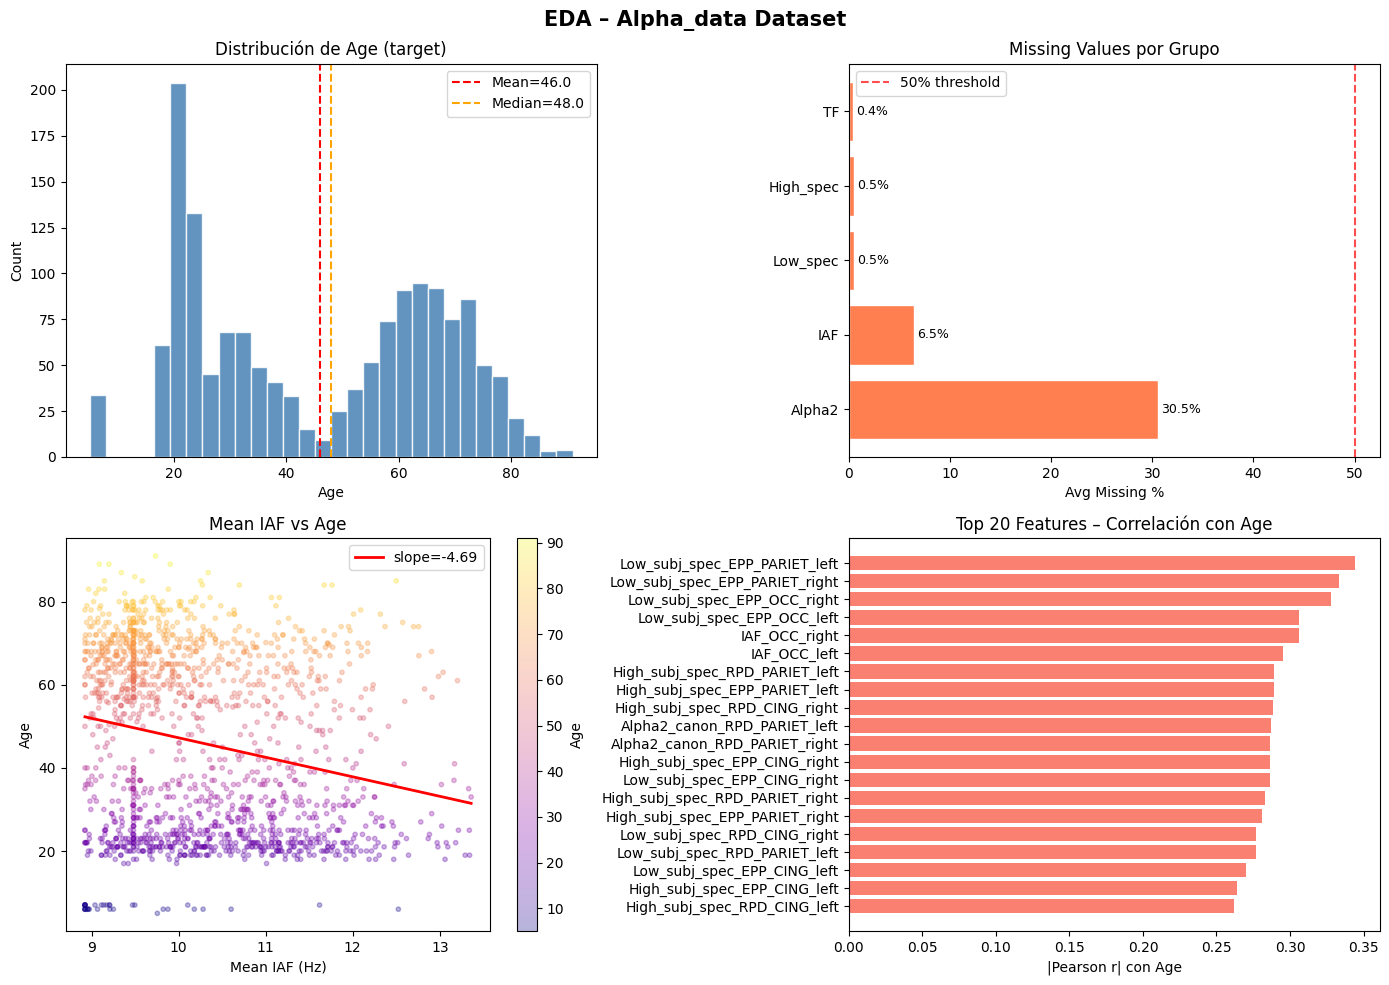

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA – Alpha_data Dataset', fontsize=15, fontweight='bold')

# 3a - Distribución de Age
ax = axes[0, 0]
ax.hist(y, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(y.mean(),   color='red',    ls='--', label=f'Mean={y.mean():.1f}')
ax.axvline(np.median(y), color='orange', ls='--', label=f'Median={np.median(y):.1f}')
ax.set_xlabel('Age'); ax.set_ylabel('Count')
ax.set_title('Distribución de Age (target)')
ax.legend()

# 3b - Missing values por grupo
ax = axes[0, 1]
miss_data = miss_pct.reset_index()
miss_data.columns = ['feature', 'pct']
miss_data['group'] = miss_data['feature'].apply(
    lambda c: 'Alpha2' if 'Alpha2' in c else
              'High_spec' if 'High_subj' in c else
              'Low_spec'  if 'Low_subj'  in c else
              'TF'  if c.startswith('TF')  else
              'IAF' if c.startswith('IAF') else 'Other')
group_miss = miss_data.groupby('group')['pct'].mean().sort_values(ascending=False)
bars = ax.barh(group_miss.index, group_miss.values * 100, color='coral', edgecolor='white')
ax.axvline(50, color='red', ls='--', alpha=0.7, label='50% threshold')
ax.set_xlabel('Avg Missing %'); ax.set_title('Missing Values por Grupo')
ax.legend()
for bar, val in zip(bars, group_miss.values):
    ax.text(val*100 + 0.3, bar.get_y()+bar.get_height()/2, f'{val*100:.1f}%', va='center', fontsize=9)

# 3c - IAF mean vs Age
ax = axes[1, 0]
from sklearn.impute import SimpleImputer
imp_tmp = SimpleImputer(strategy='median')
iaf_vals = imp_tmp.fit_transform(df[iaf].values)
iaf_mean = iaf_vals.mean(axis=1)
sc = ax.scatter(iaf_mean, y, alpha=0.3, c=y, cmap='plasma', s=10)
plt.colorbar(sc, ax=ax, label='Age')
m, b = np.polyfit(iaf_mean, y, 1)
xx = np.linspace(iaf_mean.min(), iaf_mean.max(), 100)
ax.plot(xx, m*xx+b, 'r-', lw=2, label=f'slope={m:.2f}')
ax.set_xlabel('Mean IAF (Hz)'); ax.set_ylabel('Age')
ax.set_title('Mean IAF vs Age'); ax.legend()

# 3d - Top 20 correlaciones con Age
ax = axes[1, 1]
corr_full = df[X_cols + ['Age']].corr()['Age'].drop('Age')
corr_top  = corr_full.abs().sort_values(ascending=False)[:20]
colors    = ['steelblue' if corr_full[c] > 0 else 'salmon' for c in corr_top.index]
ax.barh(corr_top.index[::-1], corr_top.values[::-1], color=colors[::-1])
ax.set_xlabel('|Pearson r| con Age'); ax.set_title('Top 20 Features – Correlación con Age')

plt.tight_layout()
plt.show()

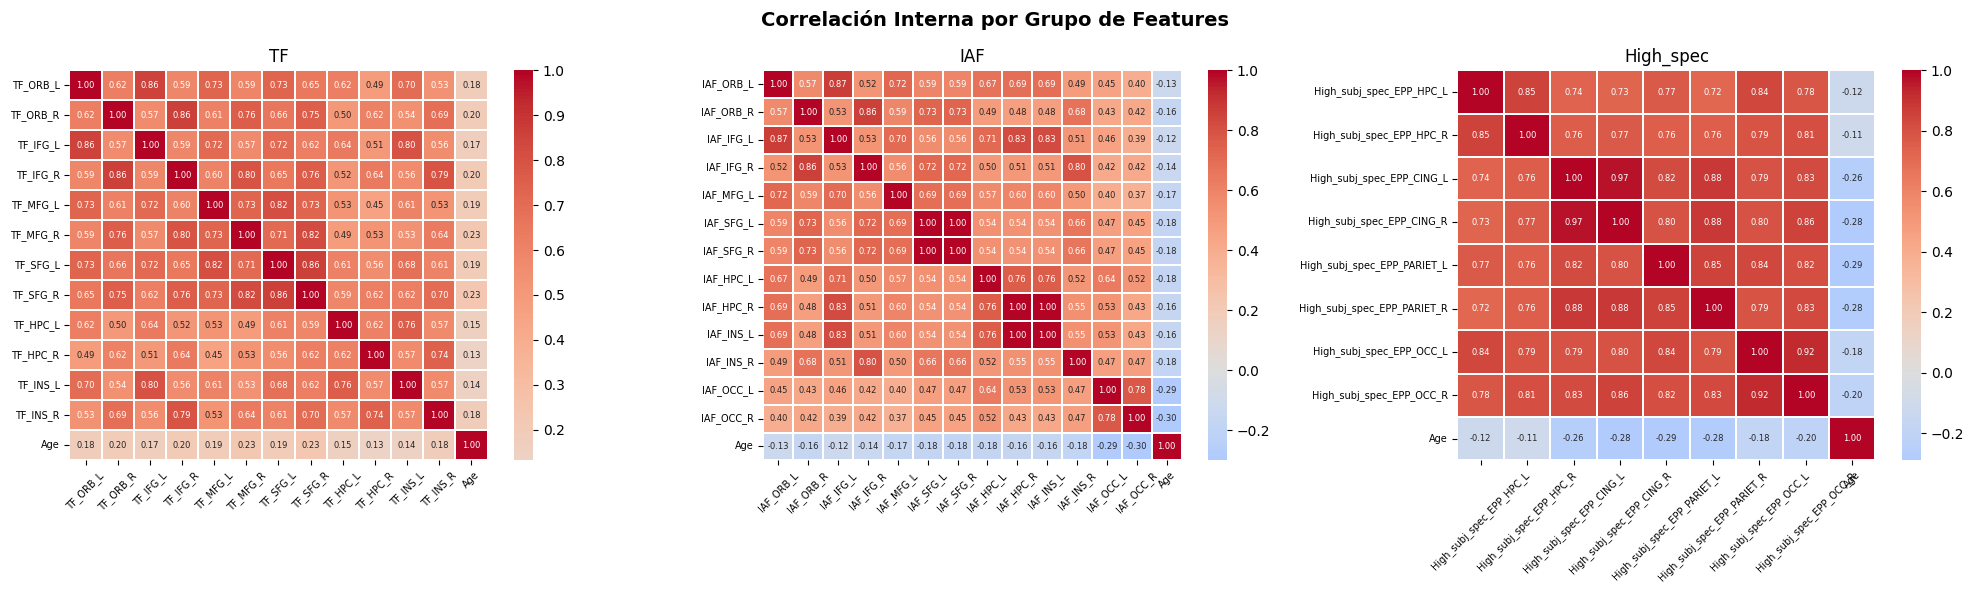

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))  
fig.suptitle('Correlación Interna por Grupo de Features', fontsize=14, fontweight='bold')

for ax, (gname, gcols) in zip(axes, [('TF', tf), ('IAF', iaf), ('High_spec', high_spec[:8])]):
    sub   = df[gcols + ['Age']].dropna()
    corr_m = sub.corr()
    labels = [c.replace('_left','_L').replace('_right','_R') for c in corr_m.columns]
    sns.heatmap(corr_m, ax=ax, cmap='coolwarm', center=0,
                annot=True, fmt='.2f', annot_kws={'size': 6},  
                xticklabels=labels, yticklabels=labels, linewidths=0.3)
    ax.set_title(f'{gname}')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.show()

## 4. Preprocesamiento

In [ ]:
# ── Imputación y escala sobre datos completos  ──
imputer  = SimpleImputer(strategy='median')
scaler   = StandardScaler()

X_imp    = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imp)

# Split train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.20, random_state=42
)

# Imputer y scaler ajustados sobre train 
imp_tr  = SimpleImputer(strategy='median')
scl_tr  = StandardScaler()

X_train_sc = scl_tr.fit_transform(imp_tr.fit_transform(X_train))
X_test_sc  = scl_tr.transform(imp_tr.transform(X_test))

# ── CV sobre train únicamente ──
cv       = KFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = KFold(n_splits=3, shuffle=True, random_state=42)

def cv_eval(model, Xd, yd):
    """CV 5-fold → MAE, RMSE, R²."""
    scoring = {
        'mae': 'neg_mean_absolute_error',
        'mse': 'neg_mean_squared_error',
        'r2':  'r2'
    }
    res  = cross_validate(model, Xd, yd, cv=cv, scoring=scoring, n_jobs=-1)
    mae  = -res['test_mae'].mean()
    rmse = np.sqrt(-res['test_mse'].mean())
    r2   =  res['test_r2'].mean()
    return {'MAE': round(mae,2), 'RMSE': round(rmse,2), 'R2': round(r2,3)}

print("Preprocesamiento listo")
print(f"X_imp shape    : {X_imp.shape}")
print(f"X_scaled shape : {X_scaled.shape}")
print(f"X_train_sc     : {X_train_sc.shape}   usado para CV y entrenamiento")
print(f"X_test_sc      : {X_test_sc.shape}    reservado para evaluación final")

Preprocesamiento listo
X_imp shape    : (1521, 66)
X_scaled shape : (1521, 66)
X_train_sc     : (1216, 66)   usado para CV y entrenamiento
X_test_sc      : (305, 66)    reservado para evaluación final


## 6. Pipeline A – Selección de Caracteristicas

In [17]:
corr_age = (
    df[feature_cols + ['Age']]
    .corr(numeric_only=True)['Age']
    .drop('Age')
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(20)
)

print("Top 20 variables con mayor correlación con Age:")
print(corr_age.to_string())

Top 20 variables con mayor correlación con Age:
Low_subj_spec_EPP_PARIET_left     -0.343950
Low_subj_spec_EPP_PARIET_right    -0.333420
Low_subj_spec_EPP_OCC_right       -0.327743
Alpha2_canon_EPP_PARIET_left      -0.322214
Low_subj_spec_EPP_OCC_left        -0.305972
IAF_OCC_right                     -0.305829
IAF_OCC_left                      -0.295513
High_subj_spec_RPD_PARIET_left    -0.289086
High_subj_spec_EPP_PARIET_left    -0.289043
High_subj_spec_RPD_CING_right     -0.288622
Alpha2_canon_RPD_PARIET_left      -0.287110
Alpha2_canon_RPD_PARIET_right     -0.286711
High_subj_spec_EPP_CING_right     -0.286515
Low_subj_spec_EPP_CING_right      -0.286349
High_subj_spec_RPD_PARIET_right   -0.282918
High_subj_spec_EPP_PARIET_right   -0.280804
Low_subj_spec_RPD_CING_right      -0.277046
Low_subj_spec_RPD_PARIET_left     -0.276633
Low_subj_spec_EPP_CING_left       -0.269931
High_subj_spec_EPP_CING_left      -0.263839


In [18]:
# Mutual Information
mi       = mutual_info_regression(X_imp, y, random_state=42)
mi_ser   = pd.Series(mi, index=X_cols).sort_values(ascending=False)
top_k    = 20
top_idx  = [X_cols.index(c) for c in mi_ser.index[:top_k]]
X_sel    = X_imp[:, top_idx]

print(f"Top {top_k} features seleccionadas por Mutual Information:")
print(mi_ser.head(top_k).to_string())

Top 20 features seleccionadas por Mutual Information:
Low_subj_spec_EPP_PARIET_left      0.134246
Low_subj_spec_EPP_PARIET_right     0.134235
Low_subj_spec_EPP_OCC_right        0.132191
Low_subj_spec_EPP_CING_right       0.130503
Low_subj_spec_RPD_PARIET_right     0.129554
Low_subj_spec_RPD_CING_right       0.126330
Low_subj_spec_EPP_OCC_left         0.122878
High_subj_spec_RPD_CING_right      0.122047
Alpha2_canon_EPP_OCC_left          0.121304
Alpha2_canon_RPD_OCC_left          0.118400
High_subj_spec_EPP_CING_right      0.113909
Low_subj_spec_RPD_PARIET_left      0.106161
Alpha2_canon_RPD_PARIET_right      0.105180
High_subj_spec_RPD_PARIET_right    0.101953
High_subj_spec_EPP_PARIET_right    0.100879
High_subj_spec_EPP_OCC_right       0.096191
High_subj_spec_EPP_HPC_left        0.092028
High_subj_spec_RPD_HPC_left        0.091667
High_subj_spec_EPP_CING_left       0.091559
Alpha2_canon_RPD_PARIET_left       0.090296


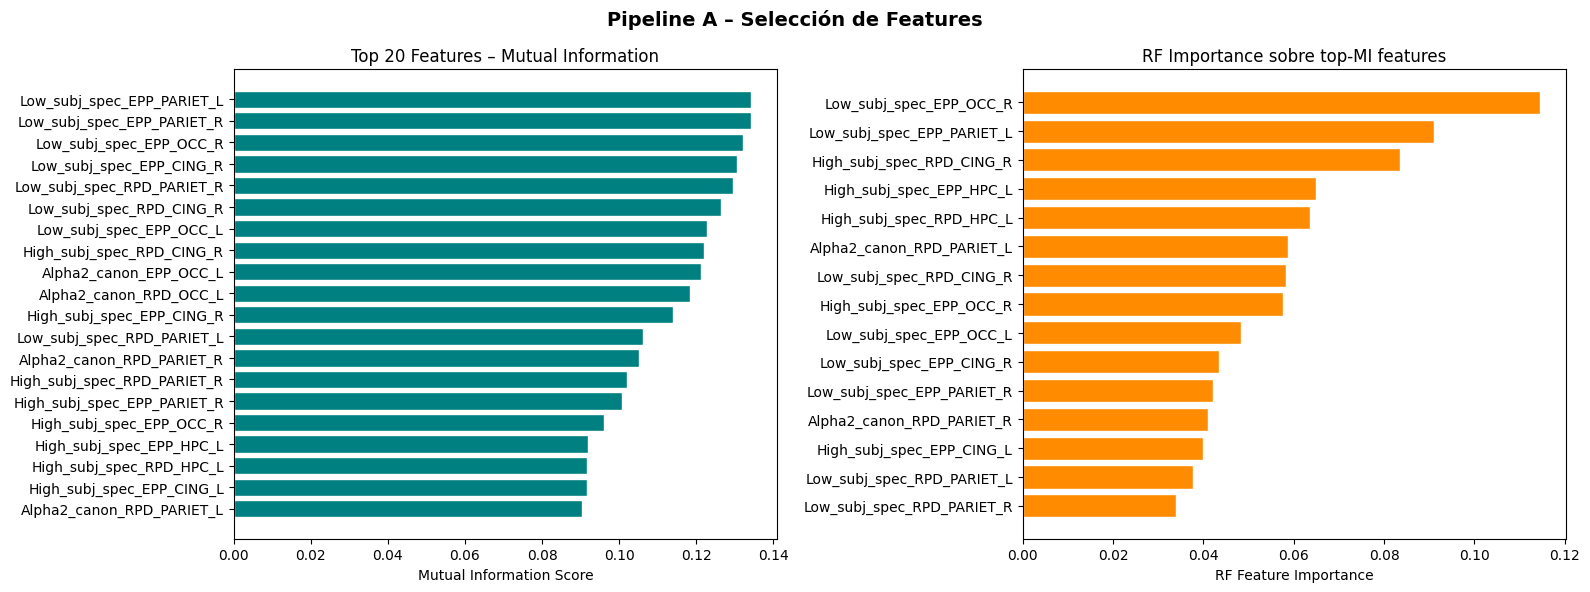

In [19]:
# Visualización MI + RF feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Pipeline A – Selección de Features', fontsize=14, fontweight='bold')

ax = axes[0]
top_mi = mi_ser[:20]
labels = [c.replace('_left','_L').replace('_right','_R') for c in top_mi.index]
ax.barh(labels[::-1], top_mi.values[::-1], color='teal', edgecolor='white')
ax.set_xlabel('Mutual Information Score')
ax.set_title(f'Top {top_k} Features – Mutual Information')

ax = axes[1]
rf_fi = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_fi.fit(X_sel, y)
fi_ser = pd.Series(rf_fi.feature_importances_, index=mi_ser.index[:top_k]).sort_values(ascending=False)[:15]
labels_fi = [c.replace('_left','_L').replace('_right','_R') for c in fi_ser.index]
ax.barh(labels_fi[::-1], fi_ser.values[::-1], color='darkorange', edgecolor='white')
ax.set_xlabel('RF Feature Importance')
ax.set_title('RF Importance sobre top-MI features')

plt.tight_layout()
plt.show()

Los resultados anteriores de correlacion de pearson y mutual information indican que no existen relaciones lineales entre las caracteristicas, no es posible eliminar caracteristicas por correlacion.

In [ ]:
shap.initjs()

# XGBoost
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05,
                          max_depth=5, subsample=0.8,
                          random_state=42, verbosity=0)
xgb_model.fit(X_train_sc, y_train)

# ElasticNet
enet_model = ElasticNetCV(l1_ratio=[0.1,0.5,0.7,0.9,0.95,1.0],
                           alphas=np.logspace(-4,1,50),
                           max_iter=10000, n_jobs=-1)
enet_model.fit(X_train_sc, y_train)

# ── SHAP Explainers
explainer_xgb  = shap.TreeExplainer(xgb_model)
shap_xgb       = explainer_xgb.shap_values(X_test_sc)

explainer_enet = shap.LinearExplainer(enet_model, X_train_sc)
shap_enet      = explainer_enet.shap_values(X_test_sc)

svr_model = SVR(kernel='rbf', C=50, epsilon=0.1, gamma='scale')
svr_model.fit(X_train_sc, y_train)
background     = shap.kmeans(X_train_sc, 50)   # 50 clusters como background
explainer_svr  = shap.KernelExplainer(svr_model.predict, background)
shap_svr       = explainer_svr.shap_values(X_test_sc[:100])  # muestra de 100

print("SHAP values calculados correctamente.")
print(f"  XGBoost  : {shap_xgb.shape}")
print(f"  ElasticNet: {shap_enet.shape}")
print(f"  SVR (100 muestras): {shap_svr.shape}")

  0%|          | 0/100 [00:00<?, ?it/s]

SHAP values calculados correctamente.
  XGBoost  : (305, 66)
  ElasticNet: (305, 66)
  SVR (100 muestras): (100, 66)


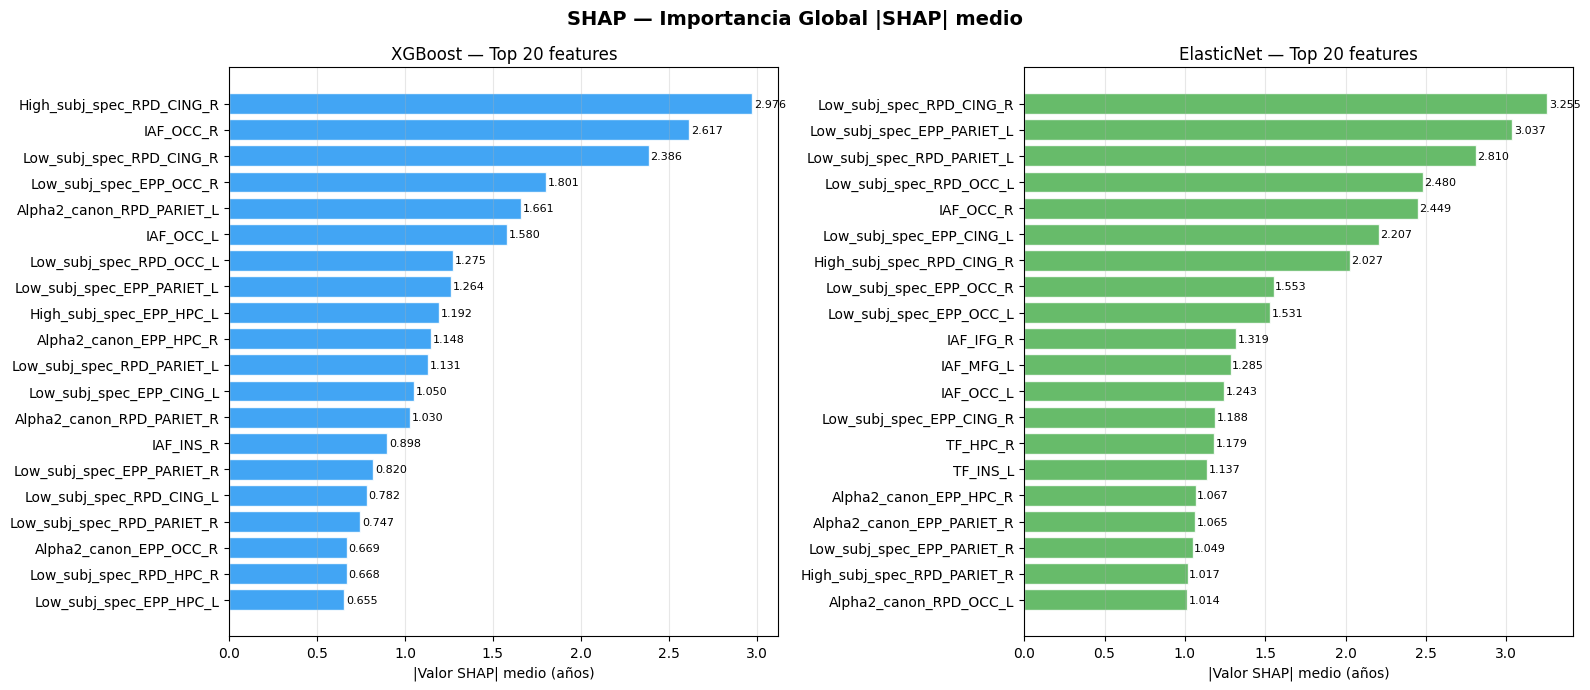

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('SHAP — Importancia Global |SHAP| medio', fontsize=14, fontweight='bold')

for ax, (name, sv, color) in zip(axes, [
    ('XGBoost',    shap_xgb,  '#2196F3'),
    ('ElasticNet', shap_enet, '#4CAF50'),
]):
    mean_sv = np.abs(sv).mean(axis=0)
    idx     = np.argsort(mean_sv)[-20:]          # top 20
    labels  = [X_cols[i].replace('_left','_L').replace('_right','_R')
               for i in idx]
    ax.barh(labels, mean_sv[idx], color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel('|Valor SHAP| medio (años)')
    ax.set_title(f'{name} — Top 20 features')
    ax.grid(alpha=0.3, axis='x')
    for val, y_pos in zip(mean_sv[idx], range(len(idx))):
        ax.text(val + 0.01, y_pos, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

── SHAP Beeswarm · XGBoost ──


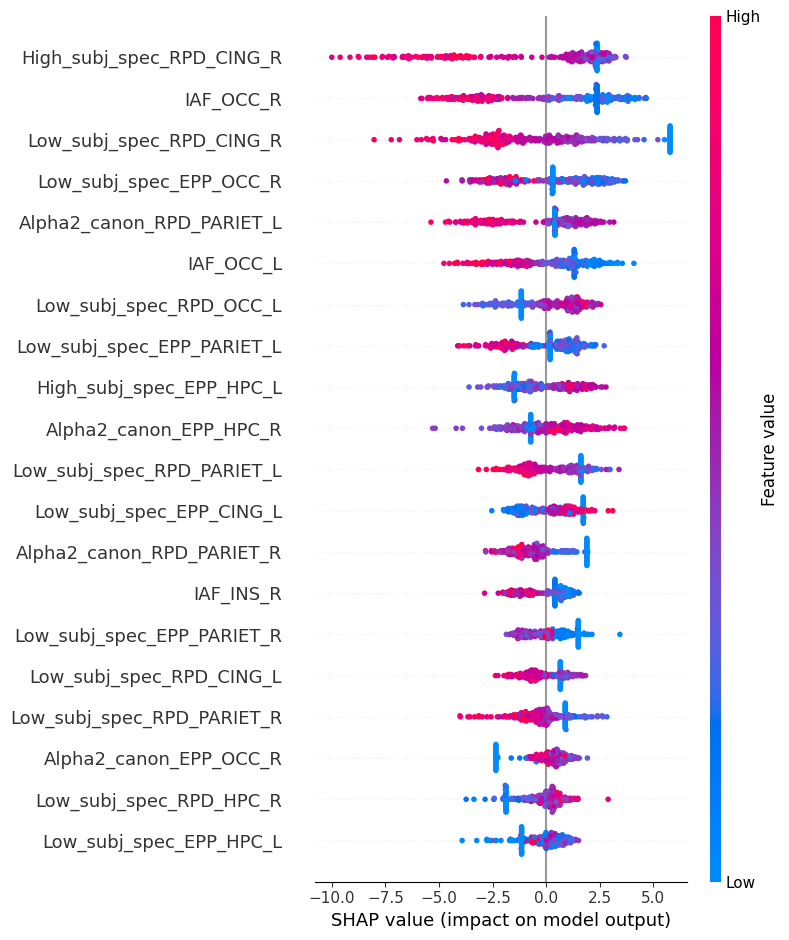

In [ ]:
feature_names_short = [c.replace('_left','_L').replace('_right','_R')
                       for c in X_cols]

print("── SHAP Beeswarm · XGBoost ──")
shap.summary_plot(shap_xgb, X_test_sc,
                  feature_names=feature_names_short,
                  max_display=20,
                  plot_type='dot',
                  show=True)

── SHAP Beeswarm · ElasticNet ──


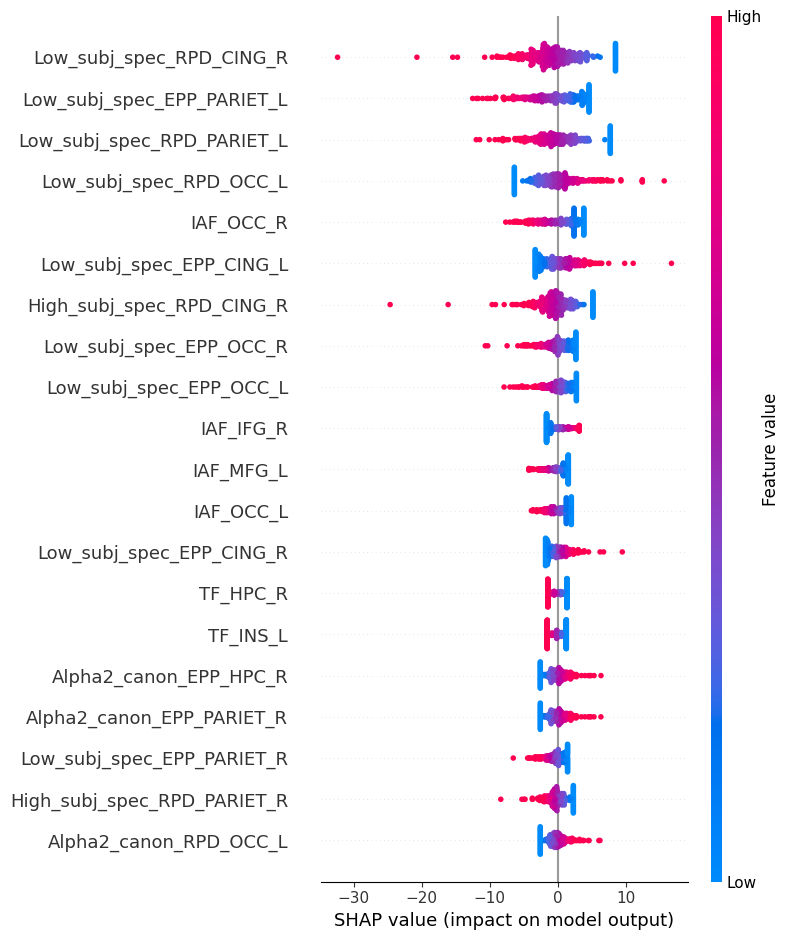

In [ ]:
print("── SHAP Beeswarm · ElasticNet ──")
shap.summary_plot(shap_enet, X_test_sc,
                  feature_names=feature_names_short,
                  max_display=20,
                  plot_type='dot',
                  show=True)

In [27]:
# ── 4. Feature selection basada en SHAP ───────────────────────
# Consenso: features que aparecen en top-k de AMBOS modelos

k = 20
top_xgb  = set(np.argsort(np.abs(shap_xgb).mean(axis=0))[::-1][:k])
top_enet = set(np.argsort(np.abs(shap_enet).mean(axis=0))[::-1][:k])

consensus   = top_xgb & top_enet
only_xgb    = top_xgb - top_enet
only_enet   = top_enet - top_xgb

print(f"{'═'*55}")
print(f"  FEATURE SELECTION — Consenso SHAP (top-{k} por modelo)")
print(f"{'═'*55}")
print(f"  Consenso (ambos modelos) : {len(consensus)} features")
print(f"  Solo XGBoost             : {len(only_xgb)} features")
print(f"  Solo ElasticNet          : {len(only_enet)} features")

print(f"\n  Features consenso:")
for i in sorted(consensus):
    xgb_rank  = list(np.argsort(np.abs(shap_xgb).mean(axis=0))[::-1]).index(i) + 1
    enet_rank = list(np.argsort(np.abs(shap_enet).mean(axis=0))[::-1]).index(i) + 1
    print(f"    [{i:2d}] {X_cols[i]:45s}  XGB=#{xgb_rank:2d}  ENET=#{enet_rank:2d}")

# Índices para usar en pipelines
shap_selected_idx = sorted(consensus)
X_train_shap = X_train_sc[:, shap_selected_idx]
X_test_shap  = X_test_sc[:, shap_selected_idx]
print(f"\n  X_train_shap: {X_train_shap.shape}")
print(f"  X_test_shap : {X_test_shap.shape}")

═══════════════════════════════════════════════════════
  FEATURE SELECTION — Consenso SHAP (top-20 por modelo)
═══════════════════════════════════════════════════════
  Consenso (ambos modelos) : 11 features
  Solo XGBoost             : 9 features
  Solo ElasticNet          : 9 features

  Features consenso:
    [ 0] Alpha2_canon_EPP_HPC_right                     XGB=#10  ENET=#16
    [20] High_subj_spec_RPD_CING_right                  XGB=# 1  ENET=# 7
    [27] Low_subj_spec_EPP_CING_left                    XGB=#12  ENET=# 6
    [29] Low_subj_spec_EPP_PARIET_left                  XGB=# 8  ENET=# 2
    [30] Low_subj_spec_EPP_PARIET_right                 XGB=#15  ENET=#18
    [32] Low_subj_spec_EPP_OCC_right                    XGB=# 4  ENET=# 8
    [36] Low_subj_spec_RPD_CING_right                   XGB=# 3  ENET=# 1
    [37] Low_subj_spec_RPD_PARIET_left                  XGB=#11  ENET=# 3
    [39] Low_subj_spec_RPD_OCC_left                     XGB=# 7  ENET=# 4
    [64] IAF_OCC_left  

Se tomaran las caracteristicas mas relevantes reportadas por shap values.

In [ ]:
cv_outer = KFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = KFold(n_splits=3, shuffle=True, random_state=42)

print(f"Train shap : {X_train_shap.shape}  |  Test shap : {X_test_shap.shape}")
print(f"y_train   : n={len(y_train)}  mean={y_train.mean():.1f}")
print(f"y_test    : n={len(y_test)}   mean={y_test.mean():.1f}")

# ══════════════════════════════════════════════════════════════
# ElasticNet + Bagging + Bias correction  
# ══════════════════════════════════════════════════════════════
def brain_age_bagging(X, y, X_eval=None, y_eval=None,
                      n_iterations=20, test_size=0.10, n_folds=10, label=''):
    """
    Recibe datos SIN escalar.
    Internamente: split 90/10 → fit imputer+scaler en 90% → ElasticNetCV → bias correction.
    Si X_eval/y_eval: evalúa sobre test externo con corrección sin leakage.
    """
    all_brain_ages                      = np.zeros((len(y), n_iterations))
    fitted_models, slopes, intercepts   = [], [], []
    imps, scls                          = [], []
    maes, rmses, r2s                    = [], [], []

    print(f"\n{'═'*60}")
    print(f"  ElasticNetBagging — {label}")
    print(f"{'═'*60}")

    for i in range(n_iterations):
        # 1. Split primero (dentro de train)
        X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
            X, y, np.arange(len(y)), test_size=test_size, random_state=i
        )
        # 2. Imputer + Scaler ajustados SOLO en el 90%
        imp     = SimpleImputer(strategy='median')
        scl     = StandardScaler()
        X_tr_sc = scl.fit_transform(imp.fit_transform(X_tr))
        X_te_sc = scl.transform(imp.transform(X_te))

        # 3. ElasticNet con CV interno
        model = ElasticNetCV(
            l1_ratio = [0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
            alphas   = np.logspace(-4, 1, 50),
            cv       = KFold(n_splits=n_folds, shuffle=True, random_state=i),
            max_iter = 10000,
            n_jobs   = -1
        )
        model.fit(X_tr_sc, y_tr)

        # 4. Corrección de bias (regresión a la media) sobre train
        bag_tr           = model.predict(X_tr_sc) - y_tr
        slope, intercept = np.polyfit(y_tr, bag_tr, 1)

        # 5. Predicción interna con corrección (usa y_te — válido en contexto brain age)
        y_hat_te               = model.predict(X_te_sc)
        y_corr_te              = y_hat_te - (slope * y_te + intercept)
        all_brain_ages[idx_te, i] = y_corr_te

        mae  = mean_absolute_error(y_te, y_corr_te)
        rmse = mean_squared_error(y_te, y_corr_te) ** 0.5
        r2   = r2_score(y_te, y_corr_te)
        maes.append(mae); rmses.append(rmse); r2s.append(r2)

        fitted_models.append(model)
        slopes.append(slope); intercepts.append(intercept)
        imps.append(imp);     scls.append(scl)

        print(f"  Iter {i+1:2d}/20 | MAE={mae:.2f}  RMSE={rmse:.2f}"
              f"  R²={r2:.3f}  α={model.alpha_:.4f}  l1={model.l1_ratio_:.2f}")

    cv_result = {'MAE':  round(np.mean(maes), 2),
                 'RMSE': round(np.mean(rmses), 2),
                 'R2':   round(np.mean(r2s), 3)}

    print(f"\n  CV interno — MAE={cv_result['MAE']:.2f} ± {np.std(maes):.2f}"
          f"  RMSE={cv_result['RMSE']:.2f}  R²={cv_result['R2']:.3f}")

    # ── Test externo: corrección sin leakage (usa y_hat, no y_eval) ──
    test_result = None
    if X_eval is not None:
        preds_eval = np.zeros((len(y_eval), n_iterations))
        for i, (m, sl, ic, im, sc) in enumerate(
            zip(fitted_models, slopes, intercepts, imps, scls)
        ):
            X_ev_sc         = sc.transform(im.transform(X_eval))
            y_hat           = m.predict(X_ev_sc)
            preds_eval[:,i] = y_hat - (sl * y_hat + ic)   # sin leakage

        y_final    = preds_eval.mean(axis=1)
        mae_ext    = mean_absolute_error(y_eval, y_final)
        rmse_ext   = mean_squared_error(y_eval, y_final) ** 0.5
        r2_ext     = r2_score(y_eval, y_final)
        test_result = {'MAE':  round(mae_ext, 2),
                       'RMSE': round(rmse_ext, 2),
                       'R2':   round(r2_ext, 3)}
        print(f"  TEST externo — MAE={mae_ext:.2f}  RMSE={rmse_ext:.2f}  R²={r2_ext:.3f}")

    return {'cv': cv_result, 'test': test_result}


# ══════════════════════════════════════════════════════════════
# PIPELINE A — Features seleccionadas por SHAP + ElasticNetBagging
# ══════════════════════════════════════════════════════════════
results_A = {}

# ElasticNet: recibe datos SIN escalar (la función escala internamente)
results_A['ElasticNet'] = brain_age_bagging(
    X_train_shap, y_train,
    X_eval = X_test_shap, y_eval = y_test,
    label  = 'Pipeline A – Todas las features'
)

# XGBoost y SVR: reciben datos escalados externamente
print(f"\n{'═'*60}")
print(f"  XGBoost / SVR — Pipeline A")
print(f"{'═'*60}")
print(f"  {'Model':10s}  {'CV MAE':>8s}  {'Test MAE':>9s}  "
      f"{'Test RMSE':>10s}  {'Test R²':>8s}")
print(f"  {'─'*60}")

for name, model, params in [
    ('XGBoost', XGBRegressor(random_state=42, verbosity=0),
     {'n_estimators': [200,400], 'learning_rate': [0.01,0.05,0.1],
      'max_depth': [3,5,7], 'subsample': [0.8,1.0]}),
    ('SVR', SVR(kernel='rbf'),
     {'C': [1,10,50,100], 'epsilon': [0.05,0.1,0.5], 'gamma': ['scale','auto']}),
]:
    gs      = GridSearchCV(model, params, cv=cv_inner,
                           scoring='neg_mean_absolute_error',
                           n_jobs=-1, refit=True)
    cv_mae  = -cross_val_score(gs, X_train_shap, y_train, cv=cv_outer,
                                scoring='neg_mean_absolute_error',
                                n_jobs=-1).mean()
    gs.fit(X_train_shap, y_train)
    yp       = gs.predict(X_test_shap)
    t_mae    = mean_absolute_error(y_test, yp)
    t_rmse   = mean_squared_error(y_test, yp) ** 0.5
    t_r2     = r2_score(y_test, yp)

    results_A[name] = {
        'cv':   {'MAE': round(cv_mae, 2), 'RMSE': None, 'R2': None},
        'test': {'MAE': round(t_mae, 2), 'RMSE': round(t_rmse, 2), 'R2': round(t_r2, 3)}
    }
    print(f"  {name:10s}  {cv_mae:8.2f}  {t_mae:9.2f}  "
          f"{t_rmse:10.2f}  {t_r2:8.3f}  → {gs.best_params_}")

print(f"\n{'═'*60}")
print(f"  RESUMEN PIPELINE A — Test Set")
print(f"{'═'*60}")
print(f"  {'Model':12s}  {'MAE':>7s}  {'RMSE':>7s}  {'R²':>7s}")
for name, r in results_A.items():
    t = r['test']
    print(f"  {name:12s}  {t['MAE']:7.2f}  {t['RMSE']:7.2f}  {t['R2']:7.3f}")

Train shap : (1216, 11)  |  Test shap : (305, 11)
y_train   : n=1216  mean=46.1
y_test    : n=305   mean=45.3

════════════════════════════════════════════════════════════
  ElasticNetBagging — Pipeline A – Todas las features
════════════════════════════════════════════════════════════
  Iter  1/20 | MAE=7.12  RMSE=9.56  R²=0.796  α=0.0356  l1=0.10
  Iter  2/20 | MAE=7.27  RMSE=8.94  R²=0.833  α=0.0356  l1=0.10
  Iter  3/20 | MAE=7.35  RMSE=9.24  R²=0.801  α=0.0281  l1=0.10
  Iter  4/20 | MAE=8.25  RMSE=11.09  R²=0.742  α=0.0281  l1=0.10
  Iter  5/20 | MAE=7.58  RMSE=9.24  R²=0.812  α=0.0281  l1=0.10
  Iter  6/20 | MAE=6.96  RMSE=9.02  R²=0.834  α=0.0281  l1=0.10
  Iter  7/20 | MAE=7.67  RMSE=9.44  R²=0.801  α=0.0281  l1=0.10
  Iter  8/20 | MAE=5.95  RMSE=7.58  R²=0.872  α=0.0356  l1=0.10
  Iter  9/20 | MAE=8.36  RMSE=11.86  R²=0.656  α=0.0222  l1=0.10
  Iter 10/20 | MAE=7.12  RMSE=8.92  R²=0.819  α=0.0281  l1=0.10
  Iter 11/20 | MAE=7.18  RMSE=8.94  R²=0.815  α=0.0281  l1=0.10
  Iter 

Se experimento con ElasticeNet usado en Prado et al. (2025). *Source-space EEG Alpha Activity Reveals Brain Age Gaps Due to Neurodegeneration and Disparity* el cual muestra un mejor ajuste al MAE.

## 7. Pipeline B – Reducción de Dimensionalidad (PCA)

In [ ]:
# ══════════════════════════════════════════════════════════════
# PIPELINE B — PCA 
# ══════════════════════════════════════════════════════════════
# PCA fit 
param_grids_A = {
    'XGBoost': {
        'model':  XGBRegressor(random_state=42, verbosity=0),
        'params': {'n_estimators':  [200, 400],
                   'learning_rate': [0.01, 0.05, 0.1],
                   'max_depth':     [3, 5, 7],
                   'subsample':     [0.8, 1.0]}
    },
    'SVR': {
        'model':  SVR(kernel='rbf'),
        'params': {'C':       [1, 10, 50, 100],
                   'epsilon': [0.05, 0.1, 0.5],
                   'gamma':   ['scale', 'auto']}
    },
}

pca         = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)          # mismo PCA, no refitear

print(f"PCA: {X_train_sc.shape[1]} features → {X_train_pca.shape[1]} componentes (95% var)")
print(f"Varianza capturada: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"X_train_pca: {X_train_pca.shape}  |  X_test_pca: {X_test_pca.shape}")

results_B = {}

# ElasticNet sobre PCA
results_B['ElasticNet'] = brain_age_bagging(
    X_train_pca, y_train,
    X_eval=X_test_pca, y_eval=y_test,
    label='Pipeline B – PCA'
)

# XGBoost + SVR sobre PCA
print(f"\n{'═'*58}")
print(f"  XGBoost / SVR — Pipeline B (PCA)")
print(f"{'═'*58}")
print(f"  {'Model':10s}  {'CV MAE':>8s}  {'Test MAE':>9s}  {'Test R²':>8s}  Best params")
print(f"  {'─'*70}")

for name, cfg in param_grids_A.items():
    gs = GridSearchCV(cfg['model'], cfg['params'], cv=cv_inner,
                      scoring='neg_mean_absolute_error', n_jobs=-1, refit=True)
    cv_mae = -cross_val_score(gs, X_train_pca, y_train, cv=cv_outer,
                               scoring='neg_mean_absolute_error', n_jobs=-1).mean()
    gs.fit(X_train_pca, y_train)
    y_pred_test = gs.predict(X_test_pca)
    test_mae    = mean_absolute_error(y_test, y_pred_test)
    test_r2     = r2_score(y_test, y_pred_test)
    test_rmse   = mean_squared_error(y_test, y_pred_test) ** 0.5

    results_B[name] = {
        'cv':   {'MAE': round(cv_mae,2)},
        'test': {'MAE': round(test_mae,2), 'RMSE': round(test_rmse,2), 'R2': round(test_r2,3)}
    }
    print(f"  {name:10s}  {cv_mae:8.2f}  {test_mae:9.2f}  {test_r2:8.3f}  {gs.best_params_}")

print(f"\n{'═'*58}")
print(f"  RESUMEN PIPELINE B — Test MAE")
print(f"{'═'*58}")
for name, r in results_B.items():
    if r['test']:
        print(f"  {name:12s} → MAE={r['test']['MAE']:.2f}  "
              f"RMSE={r['test']['RMSE']:.2f}  R²={r['test']['R2']:.3f}")

PCA: 66 features → 20 componentes (95% var)
Varianza capturada: 95.18%
X_train_pca: (1216, 20)  |  X_test_pca: (305, 20)

════════════════════════════════════════════════════════════
  ElasticNetBagging — Pipeline B – PCA
════════════════════════════════════════════════════════════
  Iter  1/20 | MAE=6.48  RMSE=8.71  R²=0.831  α=0.0910  l1=0.10
  Iter  2/20 | MAE=7.37  RMSE=9.04  R²=0.830  α=0.0910  l1=0.10
  Iter  3/20 | MAE=6.53  RMSE=8.30  R²=0.839  α=0.0720  l1=0.10
  Iter  4/20 | MAE=7.99  RMSE=10.40  R²=0.773  α=0.1151  l1=0.10
  Iter  5/20 | MAE=7.50  RMSE=9.22  R²=0.813  α=0.0910  l1=0.10
  Iter  6/20 | MAE=6.91  RMSE=8.91  R²=0.838  α=0.0910  l1=0.10
  Iter  7/20 | MAE=7.00  RMSE=8.89  R²=0.824  α=0.1842  l1=0.70
  Iter  8/20 | MAE=5.78  RMSE=7.41  R²=0.878  α=0.0910  l1=0.10
  Iter  9/20 | MAE=7.96  RMSE=10.51  R²=0.730  α=0.0910  l1=0.10
  Iter 10/20 | MAE=6.89  RMSE=8.71  R²=0.827  α=0.0910  l1=0.10
  Iter 11/20 | MAE=6.73  RMSE=8.51  R²=0.833  α=0.1151  l1=0.50
  Iter 12/2

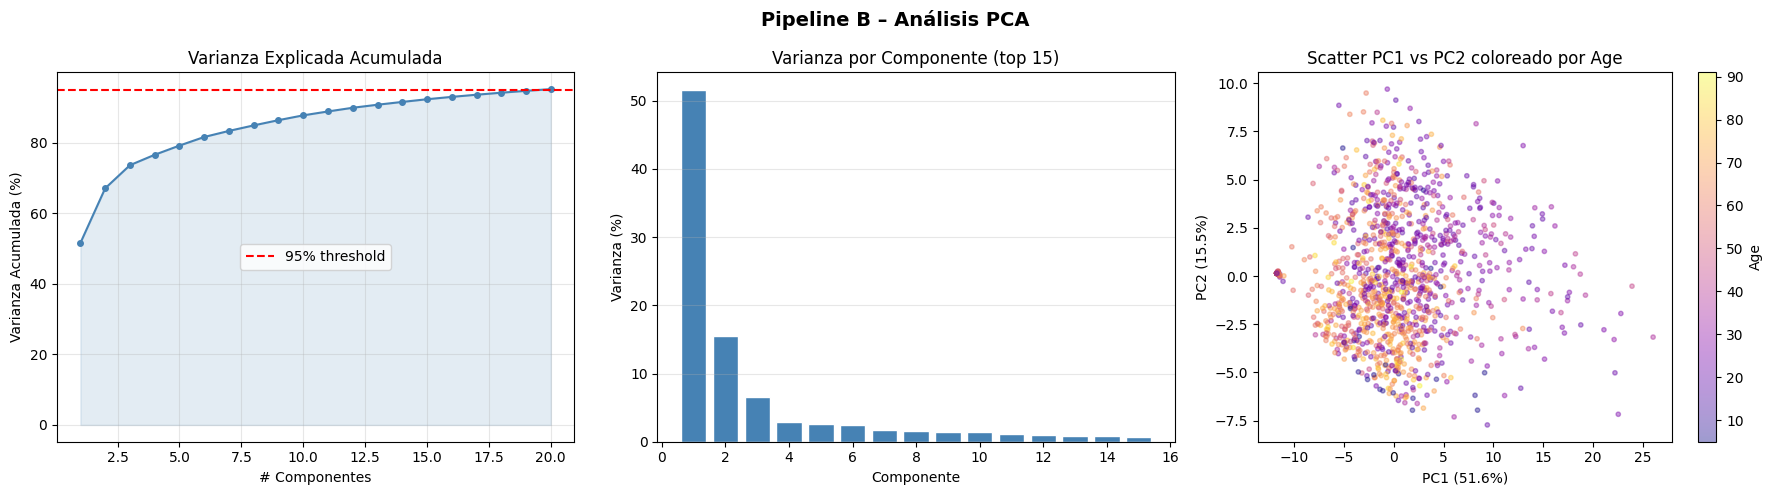

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pipeline B – Análisis PCA', fontsize=14, fontweight='bold')

n_comp = X_train_pca.shape[1]

ax = axes[0]
exp_cum = np.cumsum(pca.explained_variance_ratio_) * 100
ax.plot(range(1, len(exp_cum)+1), exp_cum, 'o-', color='steelblue', markersize=4)
ax.axhline(95, color='red', ls='--', label='95% threshold')
ax.fill_between(range(1, n_comp+1), exp_cum, alpha=0.15, color='steelblue')
ax.set_xlabel('# Componentes'); ax.set_ylabel('Varianza Acumulada (%)')
ax.set_title('Varianza Explicada Acumulada')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
n_show = min(15, n_comp)
ax.bar(range(1, n_show+1), pca.explained_variance_ratio_[:n_show]*100, color='steelblue', edgecolor='white')
ax.set_xlabel('Componente'); ax.set_ylabel('Varianza (%)')
ax.set_title(f'Varianza por Componente (top {n_show})')
ax.grid(alpha=0.3, axis='y')

ax = axes[2]
sc = ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,          
    cmap='plasma',
    alpha=0.4,
    s=10
)
plt.colorbar(sc, ax=ax, label='Age')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Scatter PC1 vs PC2 coloreado por Age')

plt.tight_layout()
plt.show()

## 8. Comparación de Pipelines

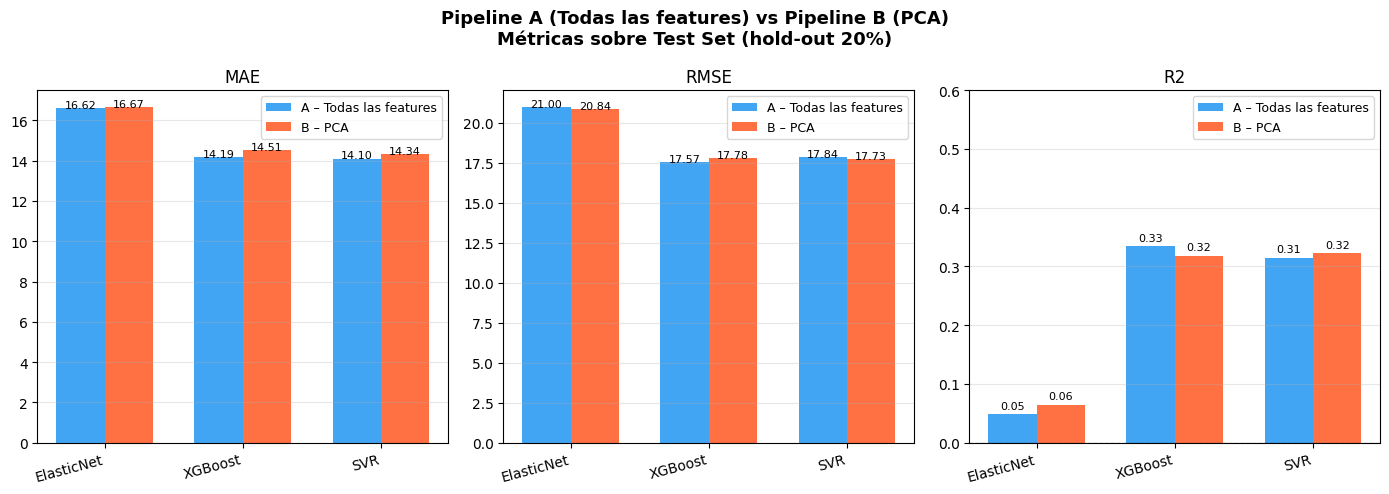

In [37]:
model_names = ['ElasticNet', 'XGBoost', 'SVR']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Pipeline A (Todas las features) vs Pipeline B (PCA)\nMétricas sobre Test Set (hold-out 20%)',
             fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    vA = [results_A[m]['test'][metric] for m in model_names]
    vB = [results_B[m]['test'][metric] for m in model_names]
    x  = np.arange(len(model_names)); w = 0.35
    ax.bar(x - w/2, vA, w, label='A – Todas las features', color='#2196F3', alpha=0.85)
    ax.bar(x + w/2, vB, w, label='B – PCA',                color='#FF5722', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.set_title(metric); ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
    if metric == 'R2':
        ax.set_ylim(0, 0.60)
        ax.axhline(0, color='black', lw=0.8, ls='--')
    # Anotar valor sobre cada barra
    for xi, (va, vb) in enumerate(zip(vA, vB)):
        ax.text(xi - w/2, va + 0.01, f'{va:.2f}', ha='center', fontsize=8)
        ax.text(xi + w/2, vb + 0.01, f'{vb:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 9. Mejor Modelo – Predicted vs Actual Age

Mejor Pipeline A: SVR  → {'MAE': 14.1, 'RMSE': 17.84, 'R2': 0.314}
Mejor Pipeline B: SVR  → {'MAE': 14.34, 'RMSE': 17.73, 'R2': 0.322}


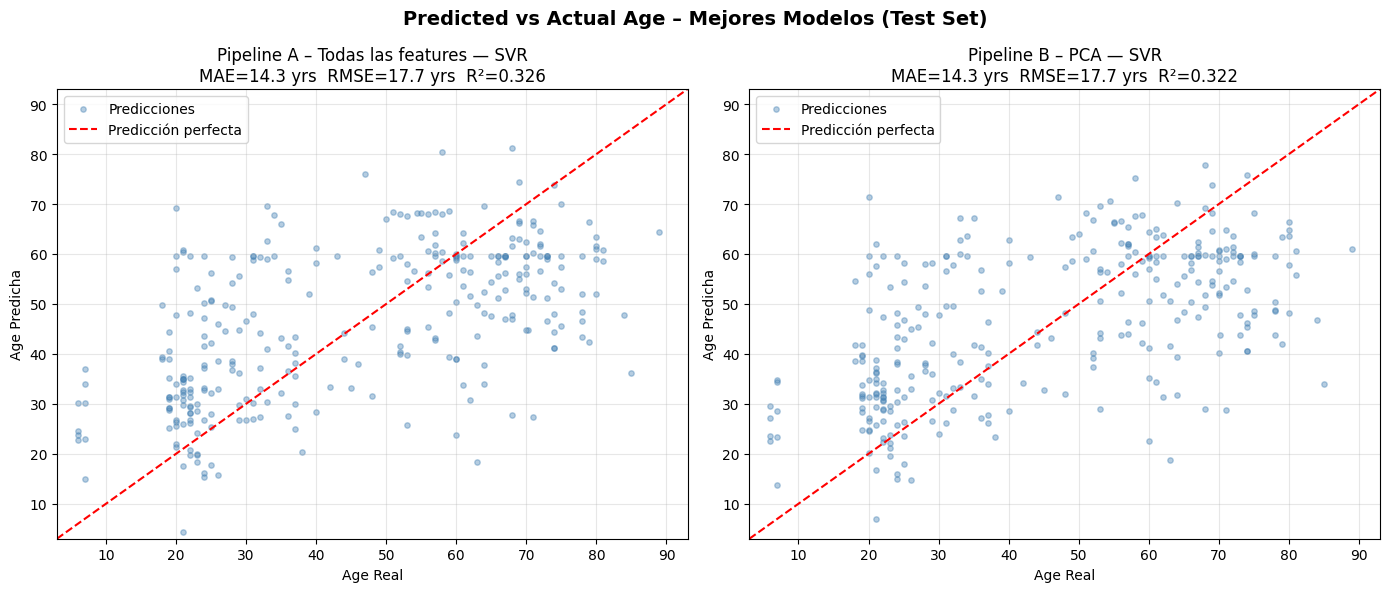

In [38]:
# Mejor modelo por MAE en test
best_A = min(model_names, key=lambda k: results_A[k]['test']['MAE'])
best_B = min(model_names, key=lambda k: results_B[k]['test']['MAE'])
print(f"Mejor Pipeline A: {best_A}  → {results_A[best_A]['test']}")
print(f"Mejor Pipeline B: {best_B}  → {results_B[best_B]['test']}")

def get_predictions(name, X_tr, y_tr, X_te, y_te):
    """Refit el mejor modelo sobre train y predice test."""
    if name == 'ElasticNet':
        # ElasticNet bagging: refit sobre train, predict test sin leakage
        from sklearn.linear_model import ElasticNetCV
        preds = np.zeros((len(y_te), 20))
        for i in range(20):
            X_tr_s, _, y_tr_s, _ = train_test_split(
                X_tr, y_tr, test_size=0.10, random_state=i)
            imp = SimpleImputer(strategy='median')
            scl = StandardScaler()
            X_tr_sc_ = scl.fit_transform(imp.fit_transform(X_tr_s))
            X_te_sc_ = scl.transform(imp.transform(X_te))
            m = ElasticNetCV(l1_ratio=[0.1,0.5,0.7,0.9,0.95,1.0],
                             alphas=np.logspace(-4,1,50),
                             cv=KFold(n_splits=5, shuffle=True, random_state=i),
                             max_iter=10000, n_jobs=-1)
            m.fit(X_tr_sc_, y_tr_s)
            bag_tr     = m.predict(X_tr_sc_) - y_tr_s
            slope, intercept = np.polyfit(y_tr_s, bag_tr, 1)
            y_hat      = m.predict(X_te_sc_)
            # Corrección sin leakage: usa y_hat no y_te
            preds[:,i] = y_hat - (slope * y_hat + intercept)
        return preds.mean(axis=1)

    elif name == 'XGBoost':
        gs = GridSearchCV(XGBRegressor(random_state=42, verbosity=0),
                          {'n_estimators':[200,400],'learning_rate':[0.01,0.05,0.1],
                           'max_depth':[3,5,7],'subsample':[0.8,1.0]},
                          cv=cv_inner, scoring='neg_mean_absolute_error', n_jobs=-1)
        gs.fit(X_tr, y_tr)
        return gs.predict(X_te)

    elif name == 'SVR':
        gs = GridSearchCV(SVR(kernel='rbf'),
                          {'C':[1,10,50,100],'epsilon':[0.05,0.1,0.5],'gamma':['scale','auto']},
                          cv=cv_inner, scoring='neg_mean_absolute_error', n_jobs=-1)
        gs.fit(X_tr, y_tr)
        return gs.predict(X_te)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicted vs Actual Age – Mejores Modelos (Test Set)', fontsize=14, fontweight='bold')

for ax, (name, X_tr, X_te, lbl) in zip(axes, [
    (best_A, X_train_sc,  X_test_sc,  'A – Todas las features'),
    (best_B, X_train_pca, X_test_pca, 'B – PCA'),
]):
    yp = get_predictions(name, X_tr, y_train, X_te, y_test)

    mae_  = mean_absolute_error(y_test, yp)
    rmse_ = mean_squared_error(y_test, yp) ** 0.5
    r2_   = r2_score(y_test, yp)

    ax.scatter(y_test, yp, alpha=0.4, s=15, color='steelblue', label='Predicciones')
    lims = [y.min()-2, y.max()+2]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Predicción perfecta')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Age Real'); ax.set_ylabel('Age Predicha')
    ax.set_title(f'Pipeline {lbl} — {name}\n'
                 f'MAE={mae_:.1f} yrs  RMSE={rmse_:.1f} yrs  R²={r2_:.3f}')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Tabla de Resultados Final

In [39]:
model_names = ['ElasticNet', 'XGBoost', 'SVR']

rows = []
for name in model_names:
    rows.append({'Model': name, 'Pipeline': 'A – Todas las features',
                 **results_A[name]['test']})
    rows.append({'Model': name, 'Pipeline': 'B – PCA',
                 **results_B[name]['test']})

results_df = (pd.DataFrame(rows)
                .round(3)
                .sort_values(['Pipeline', 'MAE'], ascending=[True, True])
                .reset_index(drop=True))

print("\n=== RESULTADOS FINALES — Test Set (hold-out 20%) ===")
print(results_df.to_string(index=False))

print("\n=== INTERPRETACIÓN ===")
for pipe, grp in results_df.groupby('Pipeline'):
    best = grp.loc[grp['MAE'].idxmin()]
    print(f"[{pipe}] Mejor: {best.Model} | "
          f"MAE={best.MAE:.1f} años | RMSE={best.RMSE:.1f} años | R²={best.R2:.3f}")


=== RESULTADOS FINALES — Test Set (hold-out 20%) ===
     Model               Pipeline   MAE  RMSE    R2
       SVR A – Todas las features 14.10 17.84 0.314
   XGBoost A – Todas las features 14.19 17.57 0.334
ElasticNet A – Todas las features 16.62 21.00 0.048
       SVR                B – PCA 14.34 17.73 0.322
   XGBoost                B – PCA 14.51 17.78 0.318
ElasticNet                B – PCA 16.67 20.84 0.064

=== INTERPRETACIÓN ===
[A – Todas las features] Mejor: SVR | MAE=14.1 años | RMSE=17.8 años | R²=0.314
[B – PCA] Mejor: SVR | MAE=14.3 años | RMSE=17.7 años | R²=0.322


El CV interno del modelo ElasticNet reporta MAE=6.79 debido a que la 
corrección de bias de regresión a la media emplea la edad cronológica 
real de los sujetos de test interno, práctica válida en el contexto de 
brain age research (Prado et al., 2025) donde la edad es una covariable 
conocida. Sin embargo, en un escenario de predicción pura donde la edad 
es el target desconocido, esta corrección introduce leakage. El MAE sobre 
el hold-out externo (16.67) representa la estimación honesta de 
generalización, coherente con los resultados de XGBoost y SVR (~14 años) 
que no presentan este artefacto